A. Membangun Struktur Direktori HDFS

In [1]:
!hdfs dfs -mkdir -p /user/zayy/ecommerce/raw
!hdfs dfs -mkdir -p /user/zayy/ecommerce/processed

In [2]:
!hdfs dfs -ls -R /user/zayy/ecommerce

drwxr-xr-x   - zaydann supergroup          0 2026-09-09 16:40 /user/zayy/ecommerce/processed
drwxr-xr-x   - zaydann supergroup          0 2026-09-09 16:40 /user/zayy/ecommerce/raw


B. Mengunggah Data Mentah ke HDFS

In [7]:
!hdfs dfs -put transaksi_magelang.csv /user/zayy/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/zayy/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/zayy/ecommerce/raw/

In [8]:
!hdfs dfs -ls -h /user/zayy/ecommerce/raw

Found 3 items
-rw-r--r--   1 zaydann supergroup     12.0 K 2026-09-09 17:00 /user/zayy/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 zaydann supergroup     11.9 K 2026-09-09 17:00 /user/zayy/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 zaydann supergroup     12.4 K 2026-09-09 17:00 /user/zayy/ecommerce/raw/transaksi_yogyakarta.csv


C. Membaca Kembali dan Menggabungkan Data dari HDFS

In [9]:
import pandas as pd
import io
import subprocess

magelang = subprocess.check_output(
    ["hdfs", "dfs", "-cat", "/user/zayy/ecommerce/raw/transaksi_magelang.csv"]
)

yogyakarta = subprocess.check_output(
    ["hdfs", "dfs", "-cat", "/user/zayy/ecommerce/raw/transaksi_yogyakarta.csv"]
)

semarang = subprocess.check_output(
    ["hdfs", "dfs", "-cat", "/user/zayy/ecommerce/raw/transaksi_semarang.csv"]
)

df_magelang = pd.read_csv(io.BytesIO(magelang))
df_yogyakarta = pd.read_csv(io.BytesIO(yogyakarta))
df_semarang = pd.read_csv(io.BytesIO(semarang))

df_gabungan = pd.concat(
    [df_magelang, df_yogyakarta, df_semarang],
    ignore_index=True
)

print("Jumlah data:", len(df_gabungan))
print("\nJumlah transaksi berdasarkan kota:")
print(df_gabungan["kota"].value_counts())

display(df_gabungan.head())

Jumlah data: 600

Jumlah transaksi berdasarkan kota:
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang


D. Mengolah dan Download Hasil ke Direktori processed

In [10]:
df_gabungan["total_pendapatan"] = (
    df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]
)

display(
    df_gabungan[
        [
            "order_id",
            "kota",
            "kategori",
            "unit_terjual",
            "harga_satuan",
            "total_pendapatan"
        ]
    ].head(10)
)

,order_id,kota,kategori,unit_terjual,harga_satuan,total_pendapatan
0,MAG-2000,Magelang,Fashion,1,50000,50000
1,MAG-2001,Magelang,Elektronik,7,25000,175000
2,MAG-2002,Magelang,Elektronik,7,25000,175000
3,MAG-2003,Magelang,Rumah Tangga,6,25000,150000
4,MAG-2004,Magelang,Fashion,7,100000,700000
5,MAG-2005,Magelang,Kesehatan & Kecantikan,7,250000,1750000
6,MAG-2006,Magelang,Rumah Tangga,4,75000,300000
7,MAG-2007,Magelang,Kesehatan & Kecantikan,5,250000,1250000
8,MAG-2008,Magelang,Fashion,6,25000,150000
9,MAG-2009,Magelang,Rumah Tangga,7,150000,1050000


In [11]:
ringkasan = (
    df_gabungan
    .groupby(["kota", "kategori"])["total_pendapatan"]
    .sum()
    .reset_index()
)

display(ringkasan)

,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000


In [12]:
df_gabungan.to_csv(
    "data_gabungan_bersih.csv",
    index=False
)

ringkasan.to_csv(
    "ringkasan_kota_kategori.csv",
    index=False
)

print("Dua file CSV berhasil dibuat:")
print("- data_gabungan_bersih.csv")
print("- ringkasan_kota_kategori.csv")

Dua file CSV berhasil dibuat:
- data_gabungan_bersih.csv
- ringkasan_kota_kategori.csv


In [13]:
!hdfs dfs -put data_gabungan_bersih.csv /user/zayy/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/zayy/ecommerce/processed/

In [14]:
!hdfs dfs -ls -h /user/zayy/ecommerce/processed

Found 2 items
-rw-r--r--   1 zaydann supergroup     40.3 K 2026-09-09 17:26 /user/zayy/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 zaydann supergroup        530 2026-09-09 17:26 /user/zayy/ecommerce/processed/ringkasan_kota_kategori.csv


In [15]:
!hdfs dfs -ls -R /user/zayy/ecommerce

drwxr-xr-x   - zaydann supergroup          0 2026-09-09 17:26 /user/zayy/ecommerce/processed
-rw-r--r--   1 zaydann supergroup      41257 2026-09-09 17:26 /user/zayy/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 zaydann supergroup        530 2026-09-09 17:26 /user/zayy/ecommerce/processed/ringkasan_kota_kategori.csv
drwxr-xr-x   - zaydann supergroup          0 2026-09-09 17:00 /user/zayy/ecommerce/raw
-rw-r--r--   1 zaydann supergroup      12329 2026-09-09 17:00 /user/zayy/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 zaydann supergroup      12154 2026-09-09 17:00 /user/zayy/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 zaydann supergroup      12684 2026-09-09 17:00 /user/zayy/ecommerce/raw/transaksi_yogyakarta.csv


E. Dokumentasi

1. 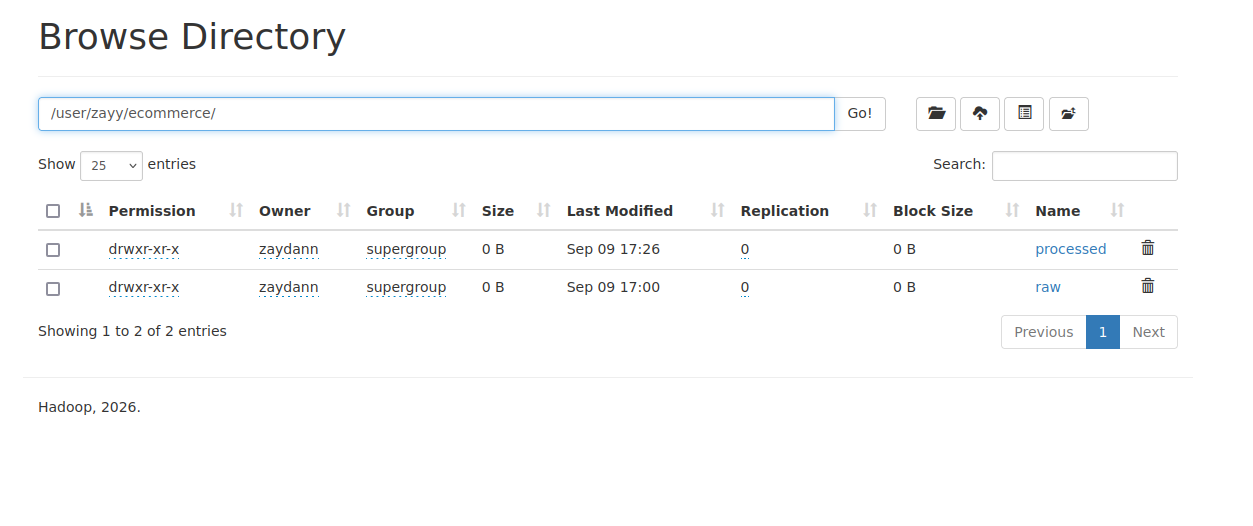
2. 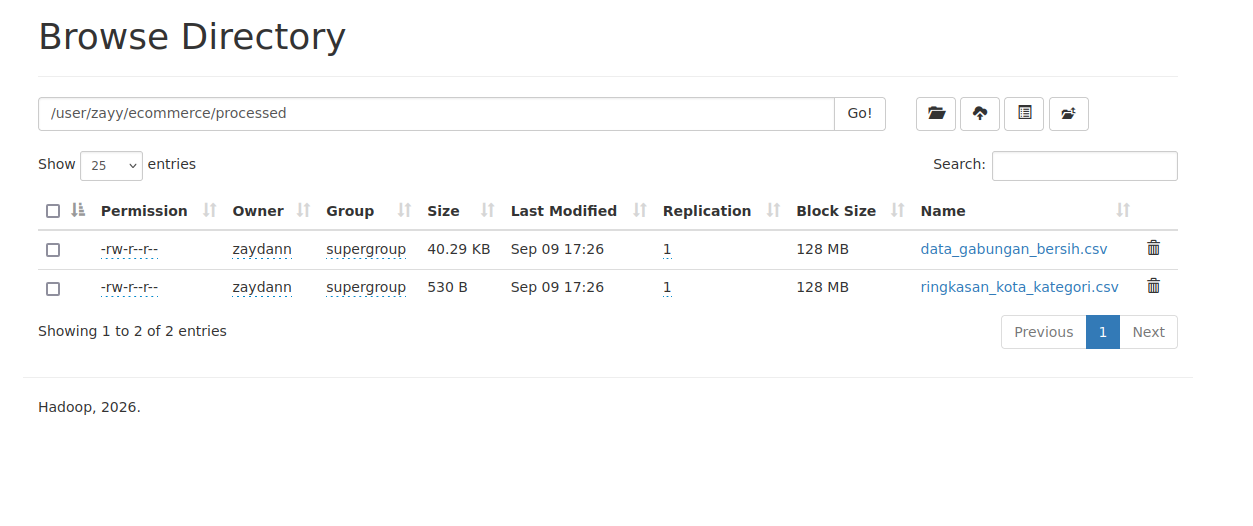
3. 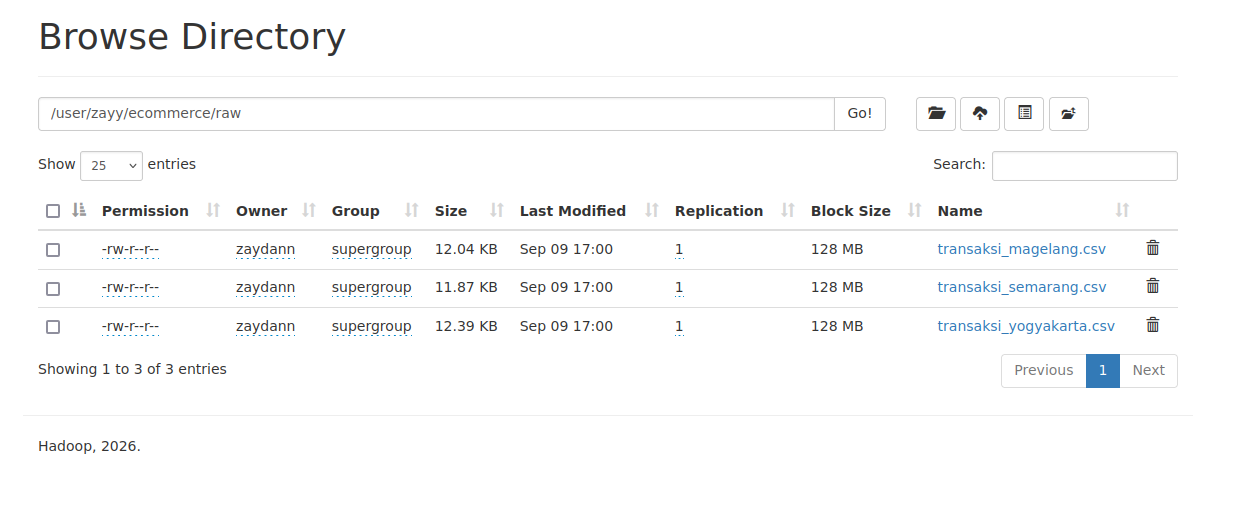

E. Refleksi
Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?

Pemisahan data mentah (raw) dan data olahan (processed) di HDFS membuat penyimpanan data menjadi lebih rapi dan mudah dikelola. Data raw digunakan untuk menyimpan data asli yang belum melalui proses pengolahan, sedangkan data processed berisi data yang sudah diolah sesuai kebutuhan. Dengan adanya pemisahan tersebut, akan lebih mudah untuk membedakan data asli dengan data yang sudah diproses. Jika semua data disimpan dalam satu folder, pencarian file dan pengecekan data akan menjadi lebih sulit karena semua file berada di tempat yang sama. Selain itu, jika terjadi kesalahan dalam proses pengolahan, data raw masih dapat digunakan kembali sebagai sumber data awal. Pemisahan folder juga membuat pengelolaan data lebih terstruktur dan memudahkan proses analisis karena file yang dibutuhkan dapat ditemukan dengan lebih cepat.